## Notebook to Demonstrate the Best-Performing Model vs. Baseline for Osteolytic Lesion Detection 

In [10]:
# Libraries

from ultralytics import YOLO
import torch
import matplotlib.pyplot as plt
import cv2
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

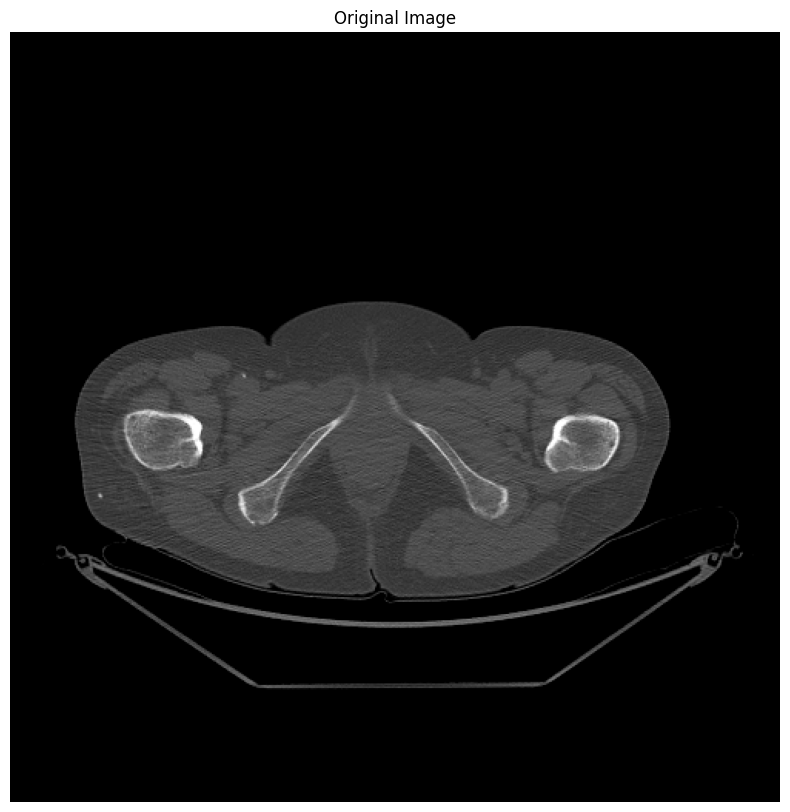

In [11]:
# Demonstration Image

image = "91_1_top_23.png"
img = cv2.imread(image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis('off')
plt.title("Original Image")
plt.show()

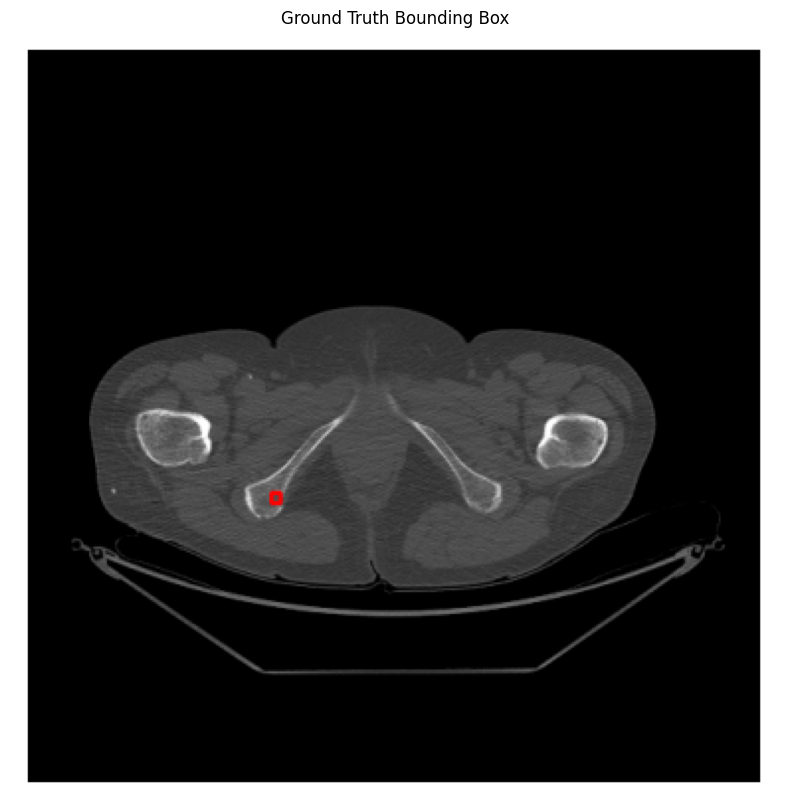

In [12]:
# Ground Truth Bounding Box around an Osteolytic Lesion

groundtruth_image = "91_1_top_23_annotated.png"
img = cv2.imread(groundtruth_image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis('off')
plt.title("Ground Truth Bounding Box")
plt.show()

# The lesion here consists of 34 pixels (which is small!)


image 1/1 /wecare/home/lotte/Thesis/CODE/analysis_and_visualization/91_1_top_23.png: 640x640 (no detections), 4.5ms
Speed: 2.1ms preprocess, 4.5ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /wecare/home/lotte/Thesis/CODE/analysis_and_visualization/runs/detect/predict2


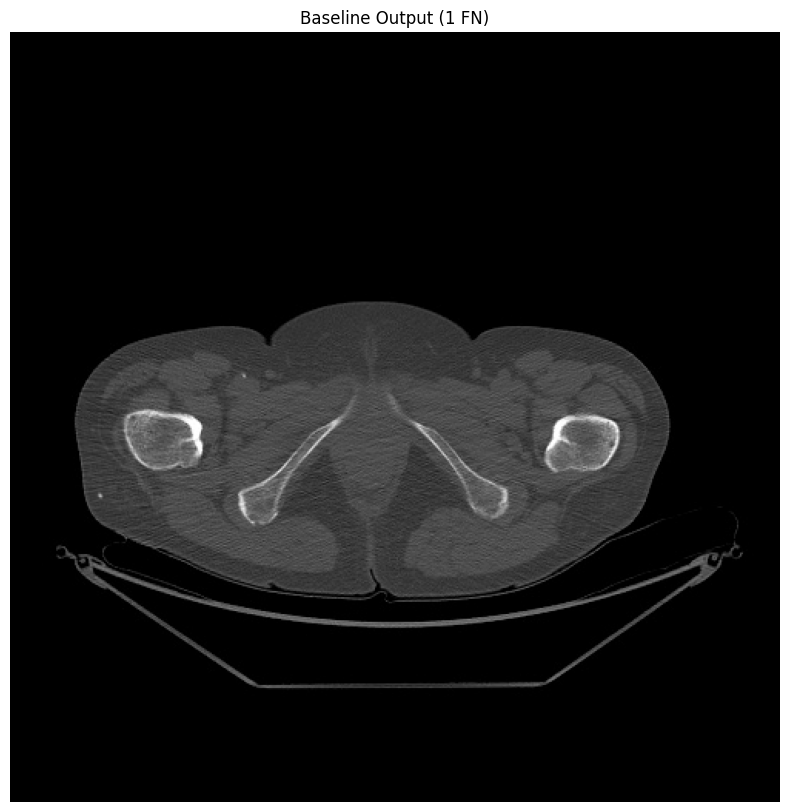

In [13]:
# Applying Baseline Model: YOLOv5s with conventional fine-tuning and evaluation methods

weights = "/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv5/base_sampled_s_train/weights/best.pt"
baseline_model = YOLO(weights)
conf = 0.218
iou = 0.1

baseline_result = baseline_model.predict(image, iou=iou, conf=conf, save=True) 

baseline_prediction = "runs/detect/predict/91_1_top_23.jpg"
img = cv2.imread(baseline_prediction)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis('off')
plt.title("Baseline Output (1 FN)")
plt.show()



image 1/1 /wecare/home/lotte/Thesis/CODE/analysis_and_visualization/91_1_top_23_side.png: 640x640 4 bones, 4.4ms
Speed: 1.9ms preprocess, 4.4ms inference, 11.1ms postprocess per image at shape (1, 3, 640, 640)
Performing prediction on 4 slices.


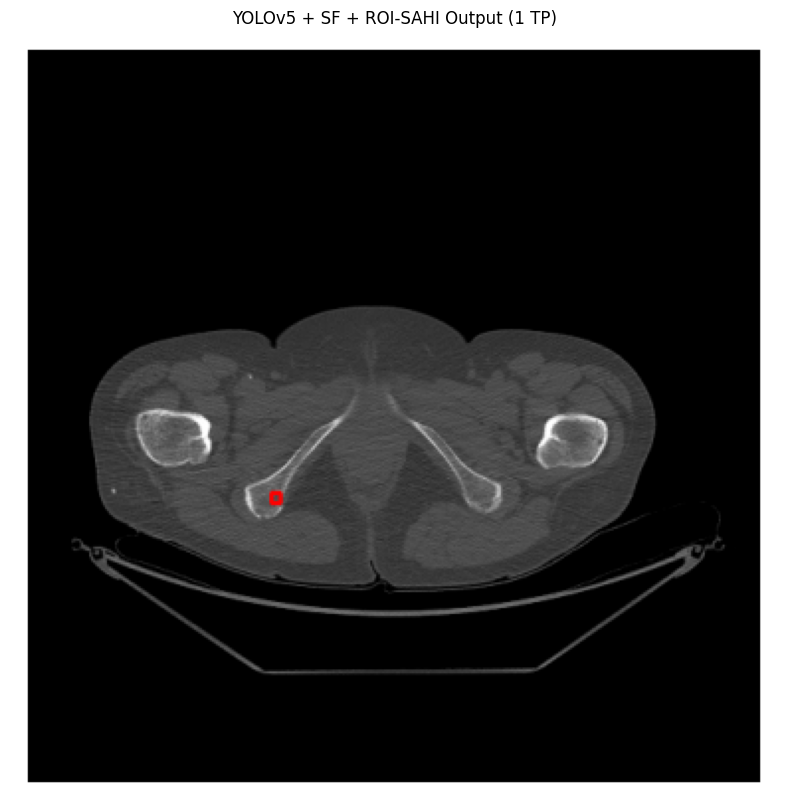

In [14]:
# Best-Performing Model: YOLOv5s + SF + ROI-SAHI

weights = "/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv5/SF_s_train/weights/best.pt"
baseline_model = YOLO(weights)
conf = 0.1
iou = 0.1

ROI_informed = True
bone_detection_model = YOLO("/wecare/home/lotte/Thesis/CODE/ETZ/pretrained_weights/yolo5s.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
detection_model = AutoDetectionModel.from_pretrained(
                model_type="ultralytics",
                model_path=weights,
                device=device,
                category_mapping={"0":"lesion"},
                confidence_threshold=conf,
        )

roisahi_results = get_sliced_prediction("91_1_top_23_side.png", detection_model, postprocess_match_threshold=iou,
                                    ROI_informed=ROI_informed, bone_detection_model=bone_detection_model)  

img = cv2.imread("roisahi_results/91_1_top_23.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis('off')
plt.title("YOLOv5 + SF + ROI-SAHI Output (1 TP)")
plt.show()
